# 🏥 Medical Insurance Cost Prediction — Comprehensive EDA & Feature Engineering

**Goal**: Understand the underlying distributions, relationships, correlations, and anomalies in the medical insurance dataset before building production pipelines.

### Key Questions to Answer:
1. How are insurance charges distributed? Is there significant skewness?
2. Which features have the strongest correlation with medical charges?
3. Does smoking status interact with BMI to create non-linear risk tiers?
4. How does applying `np.log1p` target transformation affect the normality of residuals?
5. What preprocessing strategy should be encoded into `data_transformation.py`?

In [1]:
# 1. Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

import warnings
warnings.filterwarnings('ignore')

## 2. Loading & Sanity Checks

In [2]:
# Load raw dataset
df = pd.read_csv('../Data/Raw_data.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 1338 rows, 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Dataset structure & Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
# Check for Missing Values and Duplicates
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    print("\nDuplicate row preview:")
    display(df[df.duplicated(keep=False)])

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1

Duplicate row preview:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [5]:
# Numerical Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [6]:
# Categorical Summary Statistics
df.describe(include=['O']).T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


## 3. Univariate Analysis (Single Feature Distributions)

### 3.1 Target Variable: `charges`
Let's evaluate whether insurance charges follow a normal distribution.

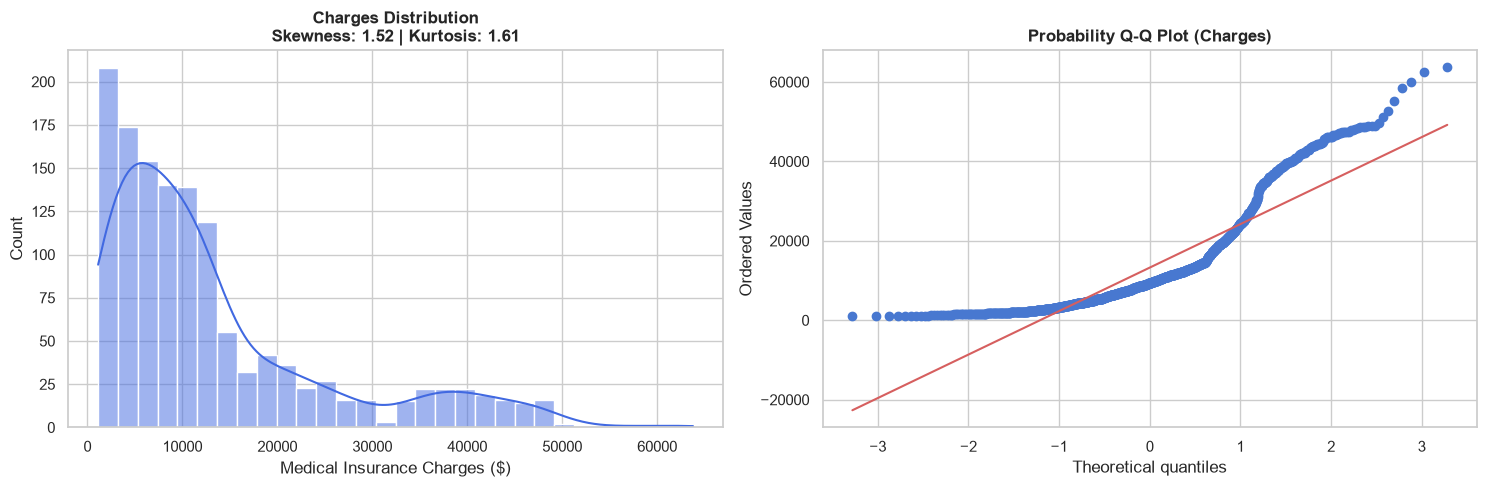

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['charges'], kde=True, color='royalblue', ax=axes[0])
axes[0].set_title(f"Charges Distribution\nSkewness: {df['charges'].skew():.2f} | Kurtosis: {df['charges'].kurt():.2f}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Medical Insurance Charges ($)")

# Q-Q Plot
stats.probplot(df['charges'], dist="norm", plot=axes[1])
axes[1].set_title("Probability Q-Q Plot (Charges)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

> **Key Finding**: `charges` has a high positive skewness of **1.51**. Most applicants have low charges (< $10,000), while a smaller subset has massive claims (> $30,000). Linear regression requires target normalization.

### 3.2 Numerical Features: `age`, `bmi`, `children`

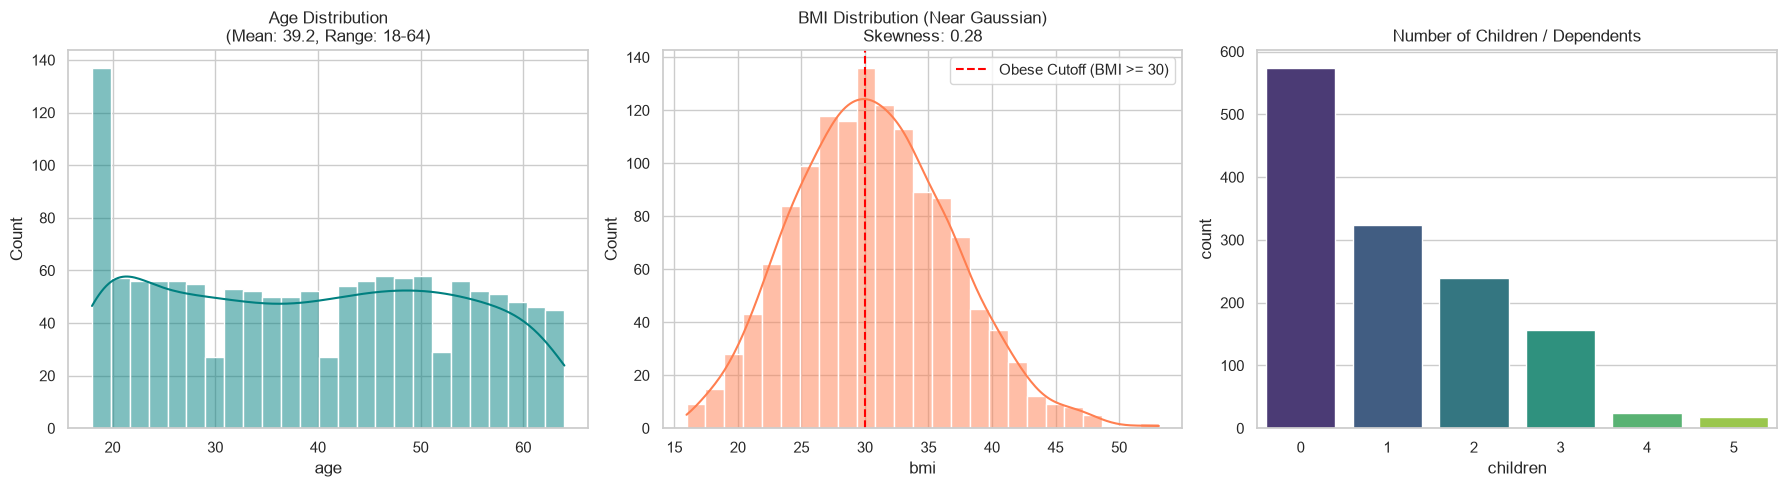

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(df['age'], kde=True, bins=25, color='teal', ax=axes[0])
axes[0].set_title(f"Age Distribution\n(Mean: {df['age'].mean():.1f}, Range: {df['age'].min()}-{df['age'].max()})")

# BMI Distribution
sns.histplot(df['bmi'], kde=True, bins=25, color='coral', ax=axes[1])
axes[1].axvline(30, color='red', linestyle='--', label='Obese Cutoff (BMI >= 30)')
axes[1].set_title(f"BMI Distribution (Near Gaussian)\nSkewness: {df['bmi'].skew():.2f}")
axes[1].legend()

# Children Count
sns.countplot(x='children', data=df, palette='viridis', ax=axes[2])
axes[2].set_title("Number of Children / Dependents")

plt.tight_layout()
plt.show()

### 3.3 Categorical Features: `sex`, `smoker`, `region`

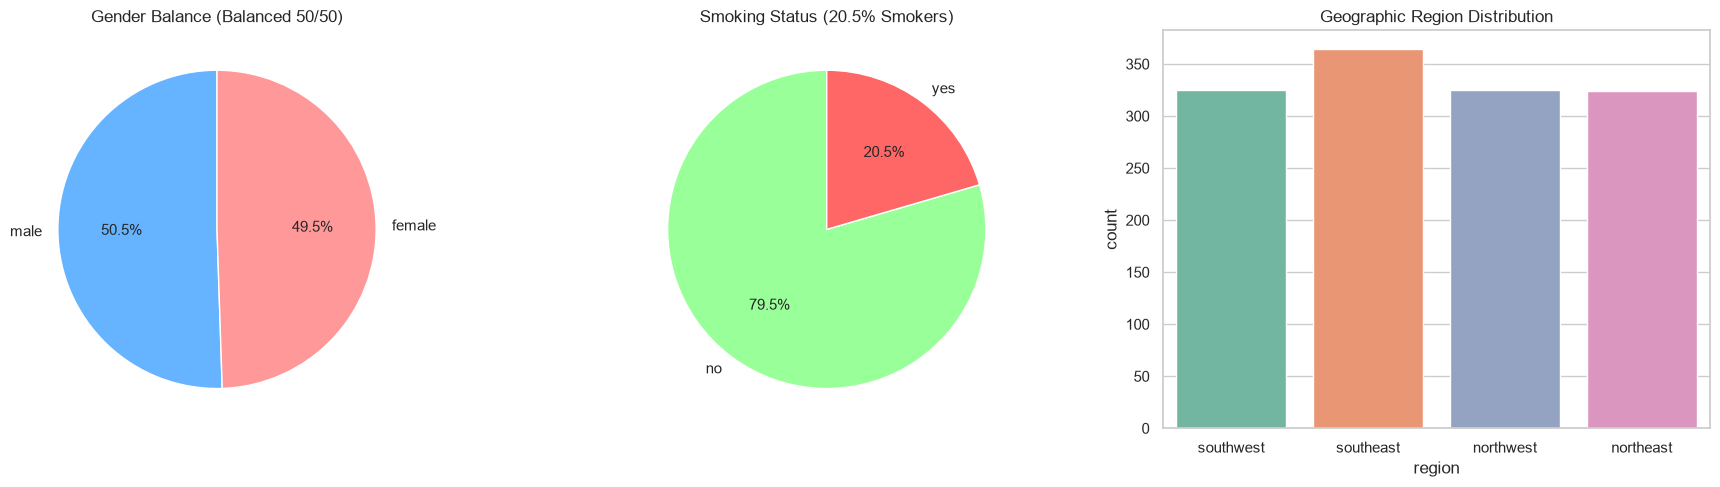

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender breakdown
df['sex'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=['#66b3ff','#ff9999'], startangle=90)
axes[0].set_title("Gender Balance (Balanced 50/50)")
axes[0].set_ylabel("")

# Smoker breakdown
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#99ff99','#ff6666'], startangle=90)
axes[1].set_title("Smoking Status (20.5% Smokers)")
axes[1].set_ylabel("")

# Region breakdown
sns.countplot(x='region', data=df, palette='Set2', ax=axes[2])
axes[2].set_title("Geographic Region Distribution")

plt.tight_layout()
plt.show()

## 4. Bivariate & Multivariate Analysis (The Real Business Insights)

### 4.1 The Smoker Factor (The #1 Price Driver)

,count,mean,median,std
smoker,,,,
no,1064,8434.268298,7345.40530,5993.781819
yes,274,32050.231832,34456.34845,11541.547176


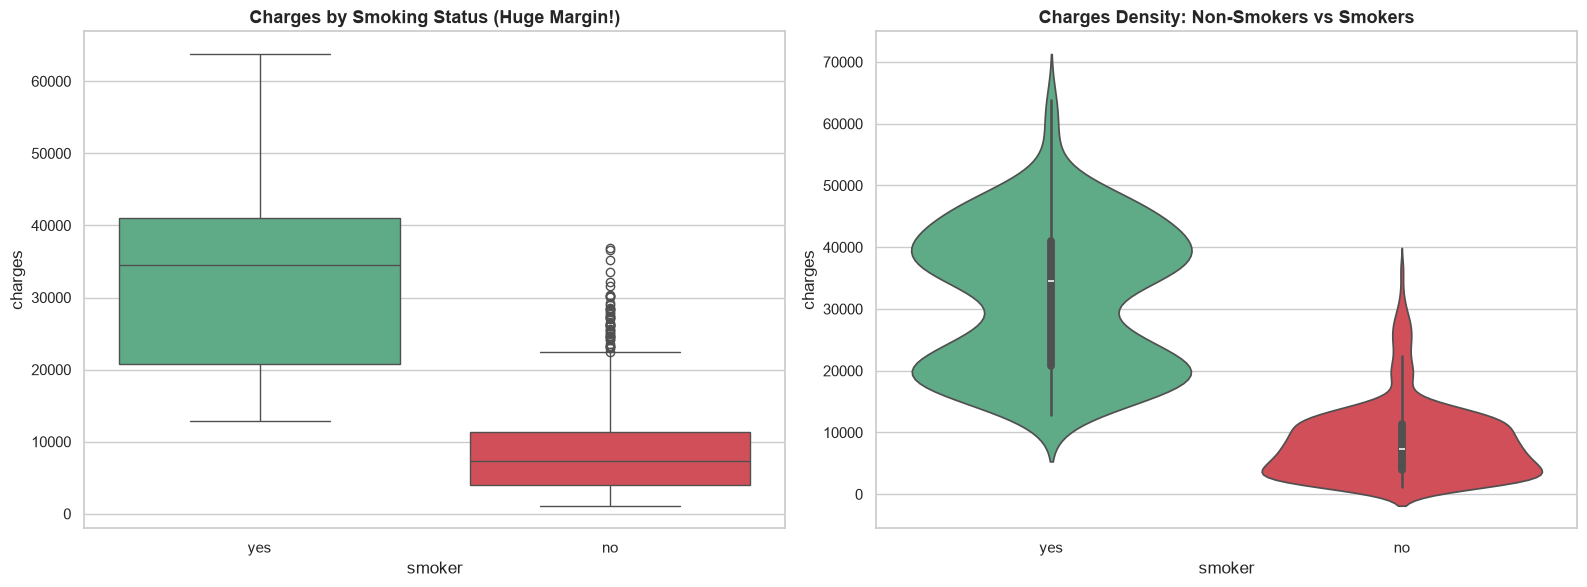

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Charges by Smoker
sns.boxplot(x='smoker', y='charges', data=df, palette=['#52B788', '#E63946'], ax=axes[0])
axes[0].set_title("Charges by Smoking Status (Huge Margin!)", fontsize=13, fontweight='bold')

# Mean/Median Table
smoker_stats = df.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'std'])
display(smoker_stats)

# Violin plot to show density concentration
sns.violinplot(x='smoker', y='charges', data=df, palette=['#52B788', '#E63946'], ax=axes[1])
axes[1].set_title("Charges Density: Non-Smokers vs Smokers", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

> **Insight**: Smokers pay on average **~$32,050/year** compared to **~$8,434/year** for non-smokers (~4x higher!). Almost every claimant with charges > $30k is a smoker.

### 4.2 Age vs Charges with Smoker Hue
Is there a linear progression with age?

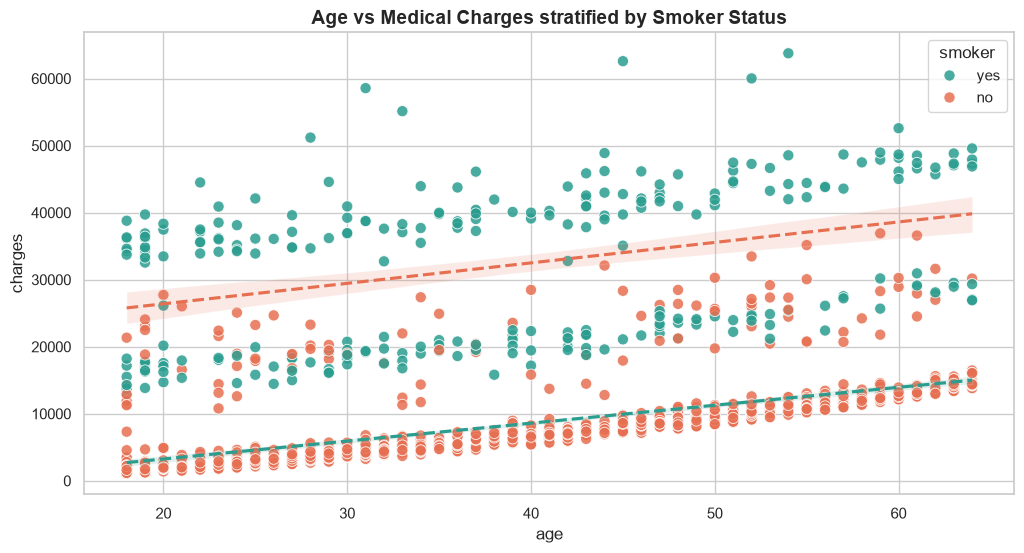

In [11]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', palette=['#2A9D8F', '#E76F51'], data=df, alpha=0.85, s=65)
plt.title("Age vs Medical Charges stratified by Smoker Status", fontsize=14, fontweight='bold')
plt.xlabel("Age (Years)")
plt.ylabel("Charges ($)")

# Regression trendlines
sns.regplot(x='age', y='charges', data=df[df['smoker']=='no'], scatter=False, color='#2A9D8F', line_kws={'linestyle':'--'})
sns.regplot(x='age', y='charges', data=df[df['smoker']=='yes'], scatter=False, color='#E76F51', line_kws={'linestyle':'--'})

plt.show()

> **Insight**: Notice the 3 distinct upward-sloping bands!
1. **Bottom Band**: Healthy non-smokers.
2. **Middle Band**: Non-smokers with health complications OR smokers with normal BMI.
3. **Top Band**: Smokers with high BMI.

### 4.3 BMI vs Charges: The Lethal Interaction with Smoking

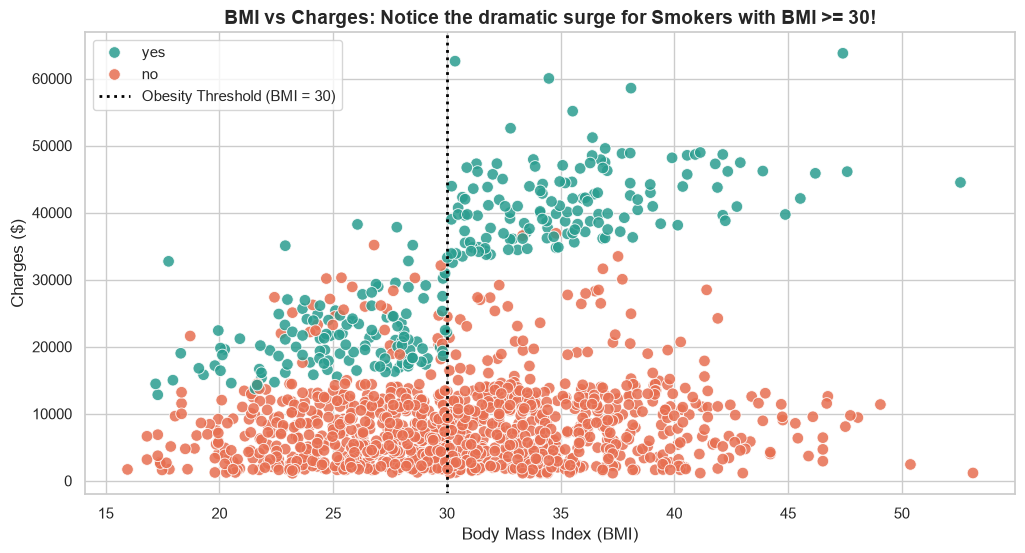

In [12]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', palette=['#2A9D8F', '#E76F51'], data=df, alpha=0.85, s=70)
plt.axvline(30, color='black', linestyle=':', linewidth=2, label='Obesity Threshold (BMI = 30)')
plt.title("BMI vs Charges: Notice the dramatic surge for Smokers with BMI >= 30!", fontsize=14, fontweight='bold')
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Charges ($)")
plt.legend()
plt.show()

> 🚨 **Critical Machine Learning Insight**: For non-smokers, higher BMI only mildly increases charges. But for **smokers with BMI >= 30**, charges explode from ~$15k straight to **$35k - $50k+**! This is a textbook non-linear interaction effect (`is_obese_smoker`). Tree-based models (Random Forest, XGBoost) capture this naturally, while linear models need interaction features.

### 4.4 Region & Gender vs Charges

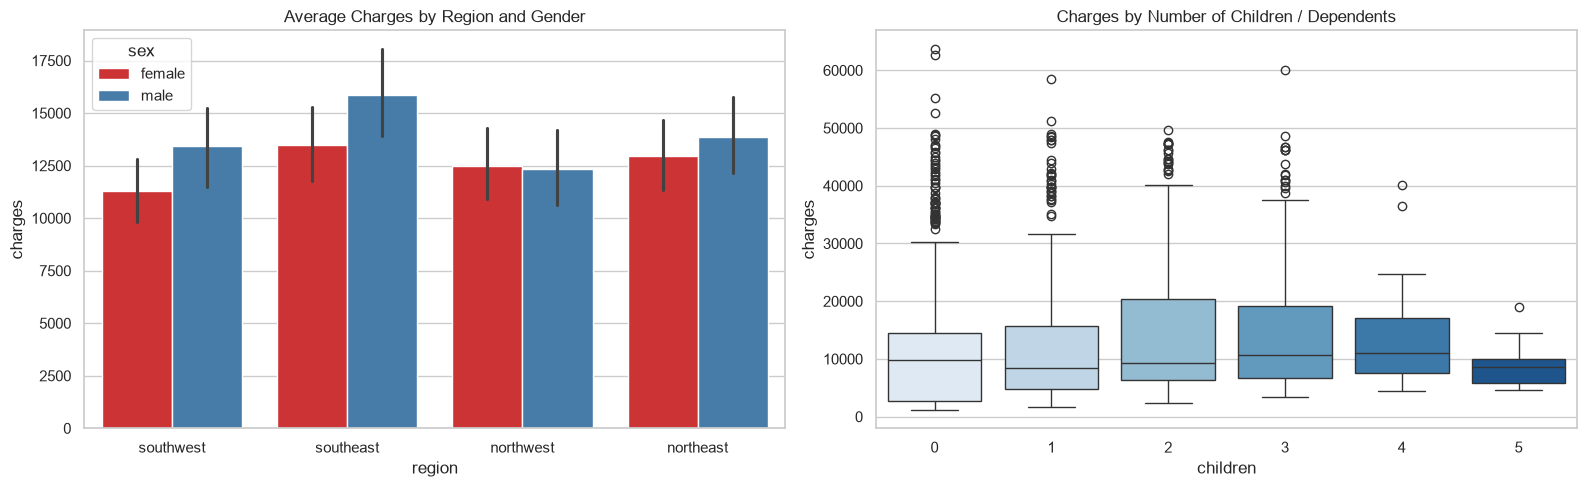

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x='region', y='charges', hue='sex', data=df, palette='Set1', ax=axes[0])
axes[0].set_title("Average Charges by Region and Gender")

sns.boxplot(x='children', y='charges', data=df, palette='Blues', ax=axes[1])
axes[1].set_title("Charges by Number of Children / Dependents")

plt.tight_layout()
plt.show()

### 4.5 Correlation Heatmap

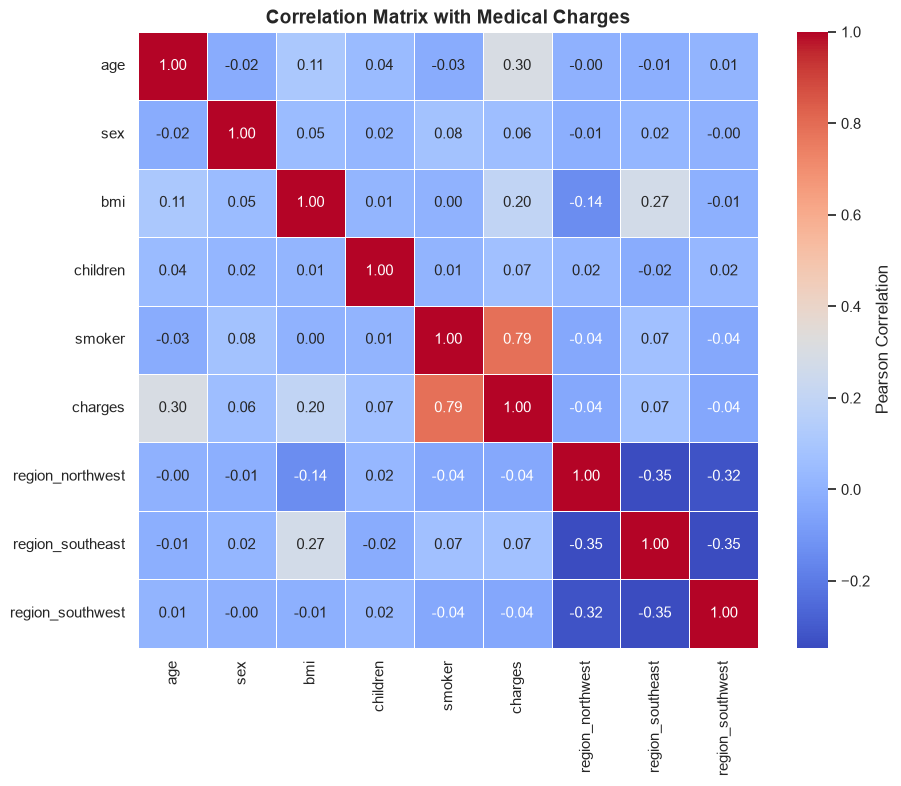

In [14]:
# Convert categorical columns to numeric codes for correlation analysis
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Correlation Matrix with Medical Charges", fontsize=14, fontweight='bold')
plt.show()

> **Correlation Summary**:
- `smoker`: **+0.79** (Extremely strong positive correlation)
- `age`: **+0.30** (Moderate positive correlation)
- `bmi`: **+0.20** (Moderate correlation)
- `children`, `sex`, `region`: Near-zero linear correlation (< 0.07)

## 5. Outlier Detection (BMI & Charges)

In [15]:
# IQR Calculation for BMI
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bmi_outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"BMI IQR Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of BMI Outliers: {len(bmi_outliers)} ({len(bmi_outliers)/len(df)*100:.2f}% of data)")
display(bmi_outliers.head())

BMI IQR Bounds: [13.70, 47.29]
Number of BMI Outliers: 9 (0.67% of data)


,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520


## 6. Target Transformation Experiment (Fixing Skewness)
Let's compare original `charges` vs `np.log1p(charges)`.

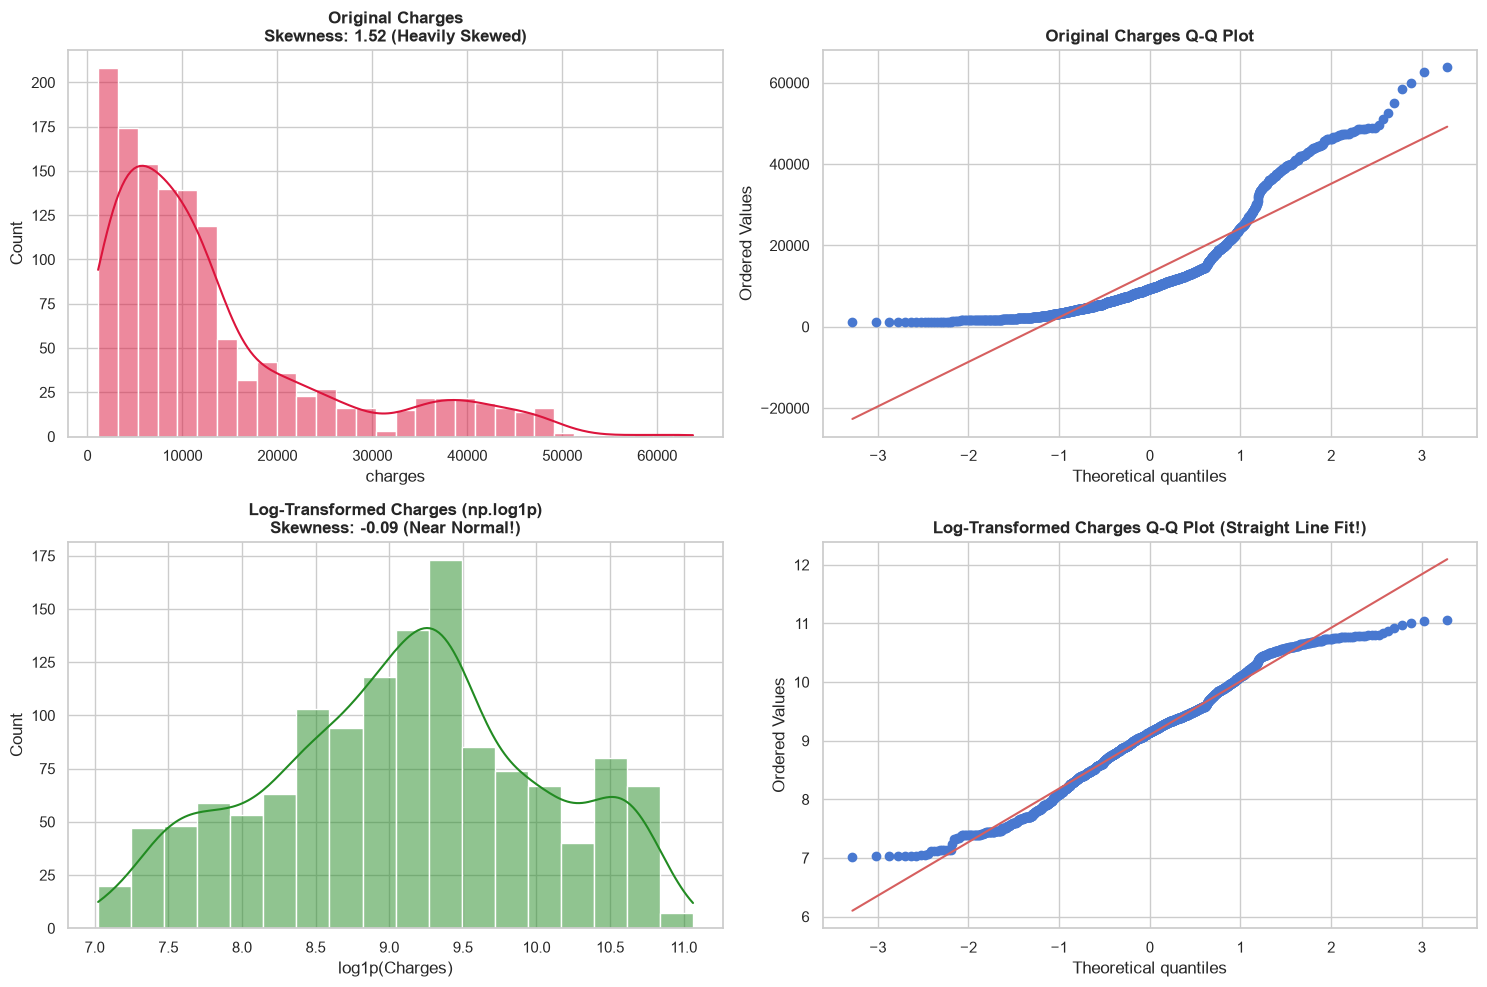

Original Skewness:        1.5159
Log-Transformed Skewness: -0.0898


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Original Charges
sns.histplot(df['charges'], kde=True, color='crimson', ax=axes[0, 0])
axes[0, 0].set_title(f"Original Charges\nSkewness: {df['charges'].skew():.2f} (Heavily Skewed)", fontweight='bold')

stats.probplot(df['charges'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Original Charges Q-Q Plot", fontweight='bold')

# 2. Log-Transformed Charges (log1p)
log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, color='forestgreen', ax=axes[1, 0])
axes[1, 0].set_title(f"Log-Transformed Charges (np.log1p)\nSkewness: {log_charges.skew():.2f} (Near Normal!)", fontweight='bold')
axes[1, 0].set_xlabel("log1p(Charges)")

stats.probplot(log_charges, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Log-Transformed Charges Q-Q Plot (Straight Line Fit!)", fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Original Skewness:        {df['charges'].skew():.4f}")
print(f"Log-Transformed Skewness: {log_charges.skew():.4f}")

## 7. Strategic Conclusions for Building the Production Pipeline

From our EDA, here is the exact architectural blueprint to code in `data_transformation.py` and `model_trainer.py`:

1. **Missing Values**: None found in the dataset, but in production, we should guard with `SimpleImputer(strategy='median')` for numerical and `SimpleImputer(strategy='most_frequent')` for categorical.
2. **Numerical Pipeline**: Apply `StandardScaler()` on `['age', 'bmi', 'children']` so distances and regression coefficients stay balanced.
3. **Categorical Pipeline**: Apply `OneHotEncoder(drop='first', handle_unknown='ignore')` on `['sex', 'smoker', 'region']`.
4. **Target Variable**: Train models on `np.log1p(y_train)`. In `predict_pipeline.py`, use `np.expm1(y_pred)` to convert back to true dollar insurance costs.
5. **Candidate Models**: Evaluate `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`, and `GradientBoosting/XGBoost`. Tree-based models will effortlessly capture the strong non-linear interaction between **BMI $\ge$ 30** and **Smoker**.